# 基于 LeNet-5 的手写数字识别系统 (MNIST)

## 1. 项目背景与目标 (Goal)
- **业务场景**：银行支票数字识别、邮政快递单号识别、手写表单电子化。
- **技术方案**：使用经典的卷积神经网络 LeNet-5 进行图像多分类（0-9）。
- **评估指标**：Accuracy（准确率）、Confusion Matrix（混淆矩阵）、错误样本分析。

## 2. 数据探索与预处理 (Data Preparation)
- 数据集：MNIST，包含 60000 张训练图，10000 张测试图，尺寸为 28x28 灰度图。
- 预处理计划：
  1. 归一化（将像素值从 0-255 缩放到 0-1，加速梯度下降）。
  2. 增加通道维度（适配 Keras 的 Conv2D 输入格式）。
  3. 标签进行 One-Hot 独热编码。

训练集形状: (60000, 28, 28), 测试集形状: (10000, 28, 28)


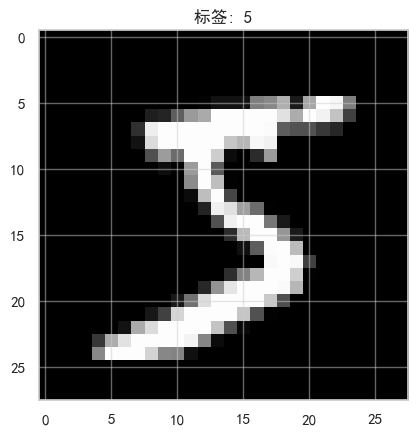

预处理后特征形状: (60000, 28, 28, 1), 标签形状: (60000, 10)


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical

# 设置可视化风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

# 1. 加载数据
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"训练集形状: {X_train.shape}, 测试集形状: {X_test.shape}")

# 2. 看看第一张图长什么样
plt.imshow(X_train[0], cmap='gray')
plt.title(f"标签: {y_train[0]}")
plt.show()

# 3. 数据预处理
# 归一化
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 增加通道维度 (60000, 28, 28) -> (60000, 28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 独热编码
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"预处理后特征形状: {X_train.shape}, 标签形状: {y_train.shape}")

## 3. LeNet-5 网络结构设计
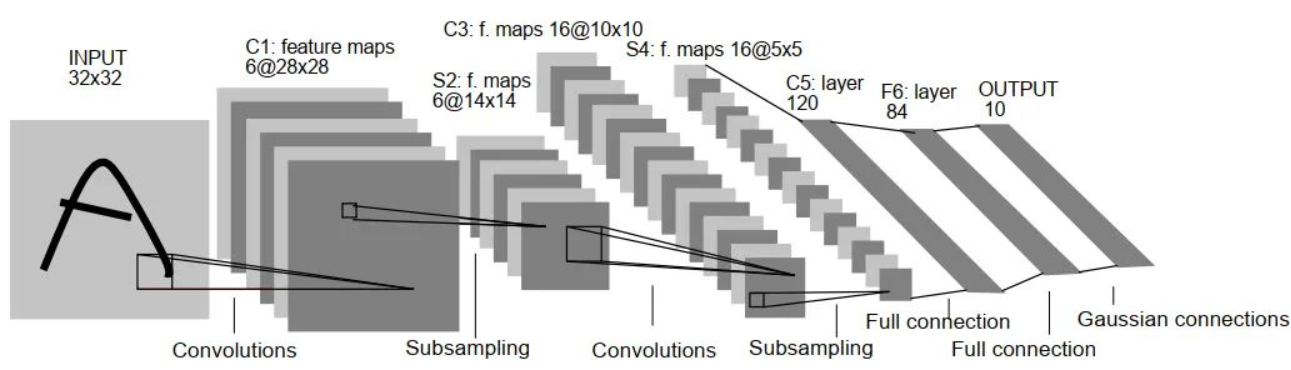

| 层号 | 类型 | 输入尺寸 | 卷积核/池化 | 输出尺寸 | 参数量 |
|---|---|---|---|---|---|
| C1 | Conv2D | 28x28x1 | 6个5x5核 | 28x28x6 | 156 |
| S2 | MaxPooling2D | 28x28x6 | 2x2 | 14x14x6 | 0 |
| C3 | Conv2D | 14x14x6 | 16个5x5核 | 10x10x16 | 2416 |
| S4 | MaxPooling2D | 10x10x16 | 2x2 | 5x5x16 | 0 |
| C5 | Conv2D | 5x5x16 | 120个5x5核 | 1x1x120 | 48120 |
| F6 | Dense | 120 | - | 84 | 10164 |
| Output | Dense | 84 | - | 10 | 850 |


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_lenet5():
    model = Sequential([
        # C1 卷积层
        Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='relu', input_shape=(28, 28, 1), padding='same'),
        # S2 池化层
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C3 卷积层
        Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid'),
        # S4 池化层
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # C5 卷积层 (相当于全连接的过渡)
        Conv2D(120, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='valid'),

        # 展平
        Flatten(),

        # F6 全连接层
        Dense(84, activation='relu'),
        # 防过拟合：Dropout
        Dropout(0.5),

        # 输出层 (10分类)
        Dense(10, activation='softmax')
    ])
    return model

model = build_lenet5()
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 28, 28, 6)         156       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 14, 14, 6)         0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 10, 10, 16)        2416      
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 5, 5, 16)          0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 1, 1, 120)         48120     
_________________________________________________________________
flatten_2 (Flatten)          (None, 120)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 84)               

## 4. 模型编译与训练策略
1. 优化器：Adam (自带学习率自适应，收敛快)
2. 损失函数：多分类交叉熵 (Categorical Crossentropy)
3. **Callbacks (回调函数)**：
   - `ModelCheckpoint`：保存验证集上表现最好的模型权重，防止训练末期过拟合。
   - `ReduceLROnPlateau`：验证集 Loss 不下降时，自动降低学习率，帮助跳出局部最优。
   - `EarlyStopping`：连续 5 轮 Loss 不下降，提前终止，节省算力。

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#  Callbacks
callbacks = [
    ModelCheckpoint('best_lenet5.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

print("🚀 开始训练 LeNet-5...")
history = model.fit(
    X_train, y_train,
    epochs=20, # 设定最大轮次，靠早停触发
    batch_size=64,
    validation_split=0.1, # 从训练集切10%做验证
    callbacks=callbacks,
    verbose=1
)

🚀 开始训练 LeNet-5...
Epoch 1/20
844/844 [==============================] - 9s 10ms/step - loss: 0.6734 - accuracy: 0.7867 - val_loss: 0.0868 - val_accuracy: 0.9738

Epoch 00001: val_loss improved from inf to 0.08684, saving model to best_lenet5.keras
Epoch 2/20
844/844 [==============================] - 9s 10ms/step - loss: 0.1143 - accuracy: 0.9678 - val_loss: 0.0518 - val_accuracy: 0.9830

Epoch 00002: val_loss improved from 0.08684 to 0.05176, saving model to best_lenet5.keras
Epoch 3/20
844/844 [==============================] - 9s 11ms/step - loss: 0.0729 - accuracy: 0.9791 - val_loss: 0.0424 - val_accuracy: 0.9882

Epoch 00003: val_loss improved from 0.05176 to 0.04237, saving model to best_lenet5.keras
Epoch 4/20
844/844 [==============================] - 10s 11ms/step - loss: 0.0591 - accuracy: 0.9825 - val_loss: 0.0417 - val_accuracy: 0.9872

Epoch 00004: val_loss improved from 0.04237 to 0.04172, saving model to best_lenet5.keras
Epoch 5/20
844/844 [=============================

## 5. 模型评估与错误分析
1. 绘制 Loss 和 Accuracy 曲线。
2. 计算测试集上的混淆矩阵 (Confusion Matrix)。
3. 找出预测错误的样本，分析原因（是字迹太潦草？还是 4 和 9 难以区分？）。

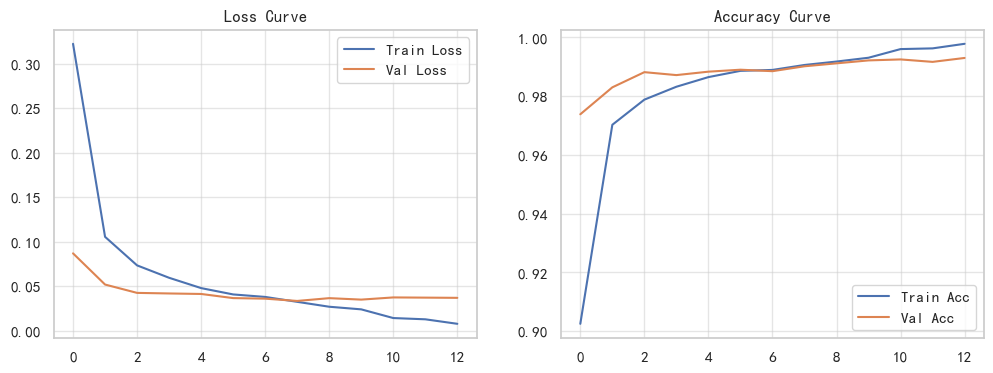

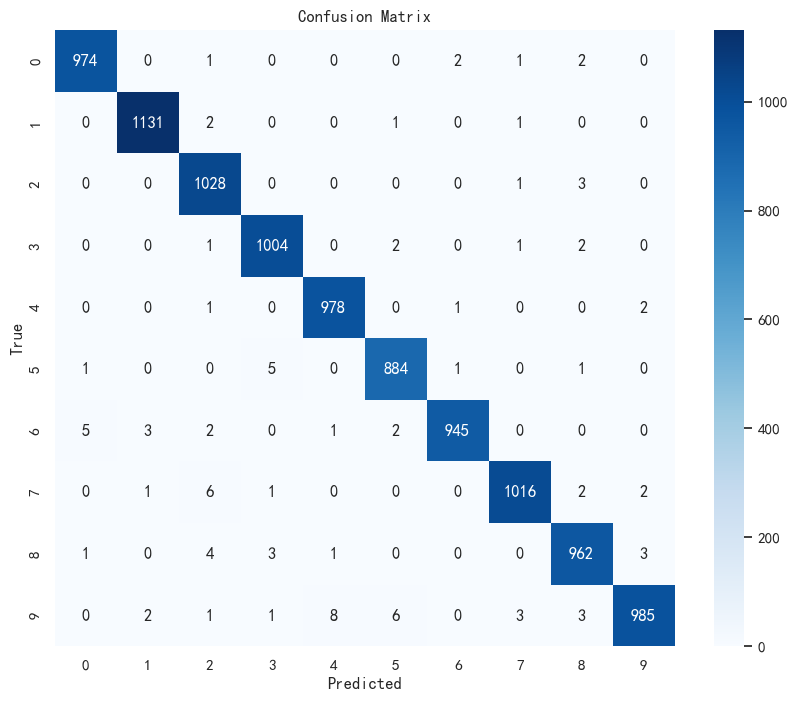


分类报告:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


总共有 93 个错误样本。展示前 5 个：


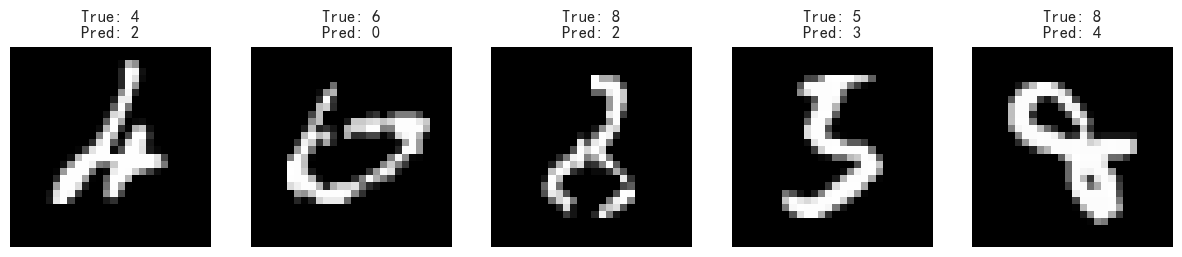

In [11]:
# 1. 绘制训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# 2. 预测并生成混淆矩阵
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\n分类报告:")
print(classification_report(y_true, y_pred))

# 3. 错误样本分析 (找出预测错误的图片)
errors = np.where(y_pred != y_true)[0]
print(f"\n总共有 {len(errors)} 个错误样本。展示前 5 个：")

plt.figure(figsize=(15, 3))
for i, idx in enumerate(errors[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')
plt.show()

# LeNet-5 项目自测

## 一、 数据理解与预处理

**Q1：为什么要除以 255？**
在你的代码里，有一行 `X_train = X_train.astype('float32') / 255.0`。请告诉我，为什么要除以 255？如果不除以 255，模型训练会发生什么？

**Q2：维度扩增的作用？**
`X_train = np.expand_dims(X_train, axis=-1)` 这行代码执行后，数据的形状发生了什么变化？为什么 Keras 的 `Conv2D` 必须要求这种形状？

**Q3：标签的独热编码**
你对标签 `y` 做了 `to_categorical(y_train, 10)` 处理。请问，如果我把这个处理删掉，模型还能训练吗？损失函数需要做什么改变？

## 二、 网络架构与数学推导

**Q4：参数量计算**
来看你的 `model.summary()`。C1 层（第一个卷积层）的输出是 28x28x6。请告诉我这层的参数量是多少？请写出计算过程。。

**Q5：C5 层的设计哲学**
你的 C5 层是 `Conv2D(120, kernel_size=(5, 5), activation='relu')`。为什么这里要用卷积层，而不是直接写 `Flatten()` 然后接 `Dense(120)`？C5 这种设计在 LeNet 论文里有什么特殊意义？

**Q6：Dropout 机制**
你在 F6 全连接层后面加了 `Dropout(0.5)`。请问：在训练阶段和推理（预测）阶段，Dropout 分别是如何工作的？

## 三、 工程与训练策略

**Q7：早停机制的权重恢复**
你使用了 `EarlyStopping`，并且设置了 `restore_best_weights=True`。如果我把这个参数改成 `False`，会对最终的测试结果产生什么影响？

**Q8：学习率衰减机制**
`ReduceLROnPlateau` 帮你在验证集 Loss 不下降时降低学习率。请问，为什么降低学习率有助于模型跳出“局部最优”或者“震荡”？

**Q9：过拟合的识别与解决**
你画了 Loss 曲线。如果 Train Loss 一直下降，但 Val Loss 在某个 epoch 后开始转头向上（上升），这说明模型出了什么问题？结合你的 LeNet 结构，你会如何在代码里解决这个问题？（至少说出两种方案）

## 四、 错误分析与实战推理

**Q10：混淆矩阵与错误分析**
通过混淆矩阵，你发现数字 5 被误认成 3（4次），8 被误认成 5（3次）。结合你刚才看到的错误样本图片，请用专业算法工程师的口吻，向面试官解释为什么会发生这种混淆，以及你接下来的优化计划。

**Q11：领域适应与真实场景泛化**
现在，你的模型已经在 MNIST 上达到了 99% 的准确率。但是，现在你接到了一个真实的工业需求：“识别银行支票上的手写数字”。
你发现，直接把 MNIST 模型搬过去，准确率暴跌到 60%。请问，真实支票上的数字（输入 X）和 MNIST 上的数字相比，可能会有什么特征分布上的不同？。